In [ ]:
import pandas as pd

# Load reviews 
df = pd.read_csv("trello_reviews_raw.csv")

# How big is the dataset? (rows, columns)
print("Shape (rows, columns):", df.shape)

# Peek at the first few rows
df.head()

Shape (rows, columns): (5000, 7)


,review_id,review_text,rating,date,helpful_count,app_version,developer_reply
0,fe518fe6-3b72-4bba-914e-f862eb88e137,So far I love this app. Definitely not what it...,5,2026-09-03 12:39:57,0,2026.17.0.80562,NaN
1,3314d120-8398-4f16-8a2a-7c8c913c025b,Last update ruined adding new items straight t...,1,2026-09-02 01:48:31,0,NaN,NaN
2,5734610b-166d-4cb9-9599-f218e7c0a1c6,Trello is a simple but powerful application. M...,5,2026-09-01 08:31:37,0,2026.17.0.80562,NaN
3,d4995cb7-e1b2-4684-b9a9-81fd8b095551,too difficult and confusing to navigate the app,2,2026-08-30 12:42:16,0,2026.17.0.80562,NaN
4,534287b1-412d-4cdb-9297-07dbe7979141,I use this app to manage my team for a project...,5,2026-08-28 10:37:24,0,2026.17.0.80562,NaN


In [5]:
# 1. What are the data types, and how many non-empty values per column?
print("=== Column info ===")
df.info()

# 2. How many empty values in each column?
print("\n=== Missing values per column ===")
print(df.isnull().sum())

# 3. Any fully duplicated reviews?
print("\n=== Exact duplicate rows ===")
print(df.duplicated().sum())

# 4. Any duplicated review text (same complaint submitted more than once)?
print("\n=== Duplicate review_text values ===")
print(df['review_text'].duplicated().sum())

=== Column info ===
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   review_id        5000 non-null   str  
 1   review_text      4999 non-null   str  
 2   rating           5000 non-null   int64
 3   date             5000 non-null   str  
 4   helpful_count    5000 non-null   int64
 5   app_version      4297 non-null   str  
 6   developer_reply  678 non-null    str  
dtypes: int64(2), str(5)
memory usage: 273.6 KB

=== Missing values per column ===
review_id             0
review_text           1
rating                0
date                  0
helpful_count         0
app_version         703
developer_reply    4322
dtype: int64

=== Exact duplicate rows ===
0

=== Duplicate review_text values ===
468


In [6]:
# Start from the raw data
print("Before cleaning:", len(df), "reviews")

# 1. Drop the review with missing text (nothing to analyze)
df_clean = df.dropna(subset=['review_text']).copy()

# 2. Drop exact-duplicate review text, keeping the first occurrence
df_clean = df_clean.drop_duplicates(subset=['review_text'], keep='first').copy()

# 3. Also strip whitespace and drop anything now empty
df_clean['review_text'] = df_clean['review_text'].str.strip()
df_clean = df_clean[df_clean['review_text'] != ''].copy()

print("After cleaning: ", len(df_clean), "reviews")
print("Removed:        ", len(df) - len(df_clean), "reviews")

Before cleaning: 5000 reviews
After cleaning:  4531 reviews
Removed:         469 reviews


Reviews per star rating:
rating
1     684
2     255
3     351
4     549
5    2692
Name: count, dtype: int64


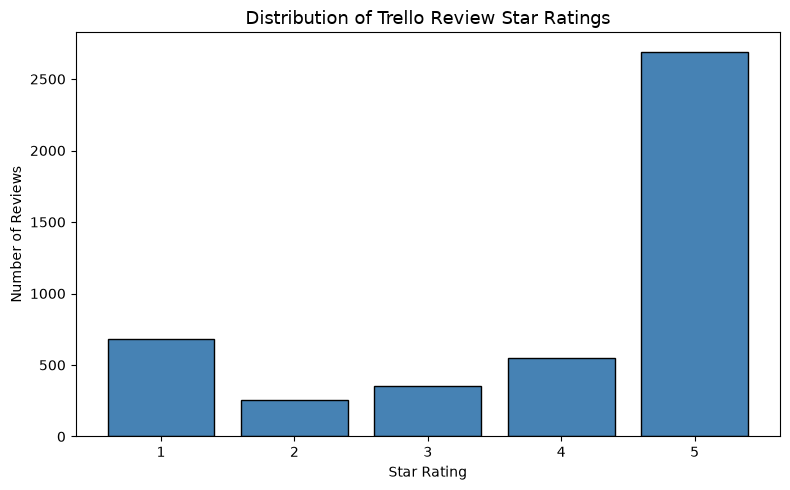

In [7]:
import matplotlib.pyplot as plt

# Count how many reviews got each star rating (1 through 5)
rating_counts = df_clean['rating'].value_counts().sort_index()
print("Reviews per star rating:")
print(rating_counts)

# Draw it as a bar chart
plt.figure(figsize=(8, 5))
plt.bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='black')
plt.title('Distribution of Trello Review Star Ratings', fontsize=13)
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.savefig('fig_rating_distribution.png', dpi=150)  # save for report
plt.show()

In [8]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Earliest review: 2018-06-07 20:54:21
Latest review:   2026-09-03 12:39:57


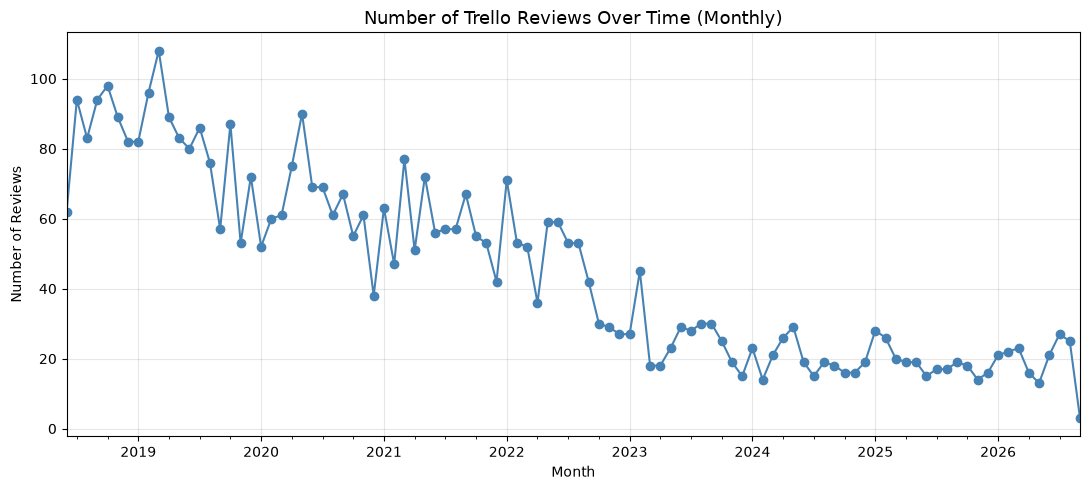

In [9]:
# Convert the 'date' column from text into real datetime values
df_clean['date'] = pd.to_datetime(df_clean['date'])

# Confirm the date range we're working with
print("Earliest review:", df_clean['date'].min())
print("Latest review:  ", df_clean['date'].max())

# Group reviews by month and count them
reviews_per_month = df_clean['date'].dt.to_period('M').value_counts().sort_index()

# Plot it as a line chart
plt.figure(figsize=(11, 5))
reviews_per_month.plot(kind='line', marker='o', color='steelblue')
plt.title('Number of Trello Reviews Over Time (Monthly)', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_reviews_over_time.png', dpi=150)
plt.show()

Review length (in words) summary:
count    4531.000000
mean       20.865372
std        22.435612
min         1.000000
25%         5.000000
50%        12.000000
75%        28.000000
max       264.000000
Name: word_count, dtype: float64

Reviews with 3 or fewer words: 745


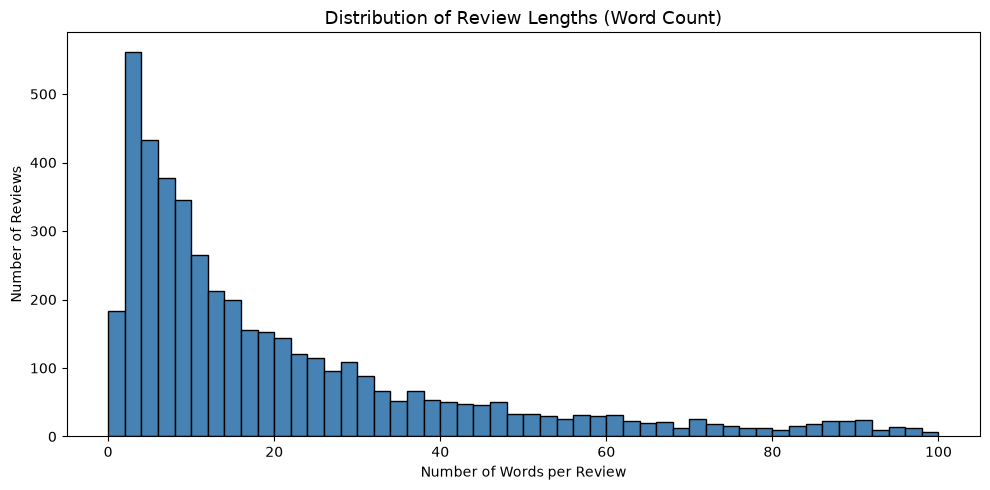

In [10]:
# Count the number of words in each review
df_clean['word_count'] = df_clean['review_text'].str.split().str.len()

# Summary statistics of review length
print("Review length (in words) summary:")
print(df_clean['word_count'].describe())

# How many reviews are very short (likely low-signal)?
print("\nReviews with 3 or fewer words:", (df_clean['word_count'] <= 3).sum())

# Plot the distribution
plt.figure(figsize=(10, 5))
plt.hist(df_clean['word_count'], bins=50, range=(0, 100),
         color='steelblue', edgecolor='black')
plt.title('Distribution of Review Lengths (Word Count)', fontsize=13)
plt.xlabel('Number of Words per Review')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.savefig('fig_review_length.png', dpi=150)
plt.show()

In [11]:
# Draw a random, reproducible sample of reviews to read
# random_state=42 is the "seed" — it makes the random draw repeatable
sample = df_clean.sample(n=40, random_state=42)

# Show the rating and full text of each, so we can read them properly
pd.set_option('display.max_colwidth', None)  # don't cut off long review text

for num, (i, row) in enumerate(sample.iterrows(), start=1):
    print(f"#{num}  [{row['rating']}★]  {row['review_text']}")
    print("-" * 80)

#1  [5★]  Used it as trial from business partner before the download today . It's excellent work tool ..,
--------------------------------------------------------------------------------
#2  [5★]  It's crazy to me that this app has offline functionality but the desktop app doesn't. Nevertheless, it's an excellent option for personal or group kanban boards, for free, with very unintrusive ads for mobile.
--------------------------------------------------------------------------------
#3  [5★]  Great To Keep Track On Things Using This App
--------------------------------------------------------------------------------
#4  [5★]  So useful
--------------------------------------------------------------------------------
#5  [5★]  Trello is the BEST... and free! It is a highly visual and flexible way to creatively organize your life. I use the app and web versions for everything from travel plans to work deadlines and it's super easy to share your custom boards with others. The "powerups" su

In [12]:
# ============================================================
# Build the manual labeling sheet: a random 200-review sample,
# excluding the 40 reviews already read during category development.
# ============================================================
import pandas as pd

# Rebuild the exact 40-review sample so we can exclude it 
earlier_40 = df_clean.sample(n=40, random_state=42)

# Draw 200 from everything EXCEPT those 40 
remaining = df_clean.drop(earlier_40.index)      # all reviews minus the 40
label_sample = remaining.sample(n=200, random_state=123)  # new seed for a fresh draw

# Build a clean table to label, with empty label columns 
sheet = label_sample[['review_id', 'review_text', 'rating', 'date']].copy()
sheet['primary_label'] = ''     
sheet['secondary_label'] = ''   

print("Reviews to label:", len(sheet))
print("Overlap with the earlier 40 (should be 0):",
      len(set(label_sample.index) & set(earlier_40.index)))
sheet.head()

Reviews to label: 200
Overlap with the earlier 40 (should be 0): 0


,review_id,review_text,rating,date,primary_label,secondary_label
573,81306653-8172-4a34-904d-9838727bd7b8,Kanban that works in webbrowser and mobile app.,5,2024-04-09 06:37:05,,
3591,3b702e71-63bf-481e-a704-4704856db7d1,Downloaded the app but can't seem to move cards around freely (unlike the web version) so there's really no point to it,1,2019-08-19 08:06:37,,
4359,10e46e7c-aa02-4257-aefb-d4ecbb2e4a9d,I use this app every day to manage and track all of my projects. I like how easy it is to use and how many features it has. My teams also like using tue app because they can see everything in the project's lifecycle all in one place.,5,2018-12-25 09:58:47,,
2819,85ae9cb9-bfec-4a42-a43b-0f60a53d1a46,Organiza minha vida inteira!,5,2020-06-17 11:37:31,,
2358,1841cab0-e3d3-43a8-acae-e8ad402c7505,Awesome app for personal tasks management.,5,2021-01-20 01:49:25,,


In [13]:
# ============================================================
# Build the Excel labeling sheet with dropdown menus + a
# reference tab listing the 10 categories.
# ============================================================
%pip install openpyxl -q

import openpyxl
from openpyxl.worksheet.datavalidation import DataValidation

# The 10 finalized categories (must match the protocol exactly)
CATEGORIES = [
    "Performance / Crashes",
    "Notifications",
    "Navigation / Usability",
    "Account / Login",
    "Boards / Task Management",
    "Integrations / Sync",
    "Feature Request",
    "Positive / No Issue",
    "Non-actionable / Unclear",
    "Other",
]

OUTPUT_FILE = "labeling_sheet.xlsx"

# --- Write the sample to Excel (main labeling tab) ---
with pd.ExcelWriter(OUTPUT_FILE, engine="openpyxl") as writer:
    sheet.to_excel(writer, sheet_name="Labeling", index=False)

    # Add a second tab listing the categories for reference
    ref = pd.DataFrame({"Category": CATEGORIES})
    ref.to_excel(writer, sheet_name="Categories", index=False)

# --- Re-open to add dropdown menus on the label columns ---
wb = openpyxl.load_workbook(OUTPUT_FILE)
ws = wb["Labeling"]

# Build the dropdown list from the categories
dropdown = DataValidation(
    type="list",
    formula1='"' + ",".join(CATEGORIES) + '"',
    allow_blank=True,
)
ws.add_data_validation(dropdown)

# primary_label is column E, secondary_label is column F
# (columns: A=review_id B=review_text C=rating D=date E=primary F=secondary)
n_rows = len(sheet) + 1  # +1 for the header row
dropdown.add(f"E2:E{n_rows}")   # dropdown on primary_label
dropdown.add(f"F2:F{n_rows}")   # dropdown on secondary_label

# Widen the review_text column so it's readable while labeling
ws.column_dimensions["B"].width = 80
ws.column_dimensions["E"].width = 24
ws.column_dimensions["F"].width = 24

wb.save(OUTPUT_FILE)
print(f"Saved {OUTPUT_FILE} with {len(sheet)} reviews and dropdown menus.")


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Saved labeling_sheet.xlsx with 200 reviews and dropdown menus.
